In [40]:
from box_world_env import BoxWorld
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

In [54]:
env = BoxWorld(
    n=8,
    goal_length=1,
    num_distractor=0,
    distractor_length=0,
    max_steps=50,
    keep_prev_world=True,
    render_mode="human",
)

obs1, info = env.reset()
obs2, info = env.reset()

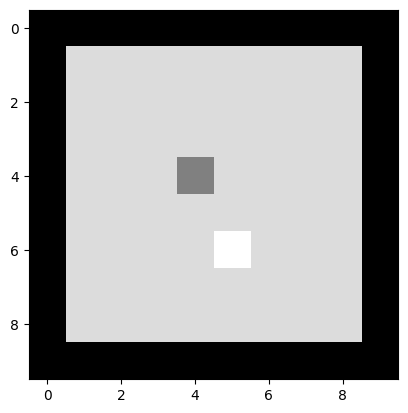

In [55]:
plt.imshow(obs1.transpose(1, 2, 0))

In [57]:
obs2

array([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 128, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 255, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0]],

       [[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 128, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 220, 220, 220, 220,   0],
        [  0, 220, 220, 220, 220, 255,

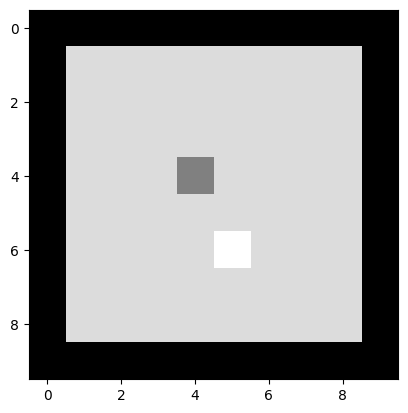

In [56]:
plt.imshow(obs2.transpose(1, 2, 0))

In [10]:
obs2.shape

(3, 10, 10)

In [12]:
from conv_gru import ConvGRU, ConvGRUCell
from torchinfo import summary

In [28]:
class ConvGRU(nn.Module):
    def __init__(
        self,
        input_shape,
        hidden_dim=64,
        kernel_size=(3, 3),
        num_layers=1,
        batch_first=True,
        bias=True,
    ):
        super().__init__()
        self.channels, self.height, self.width = input_shape
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.bias = bias

        cells = []
        for i in range(self.num_layers):
            cell_input_channels = self.channels if i == 0 else self.hidden_dim
            cells.append(
                ConvGRUCell(
                    input_shape=(cell_input_channels, self.height, self.width),
                    hidden_dim=self.hidden_dim,
                    kernel_size=self.kernel_size,
                    bias=self.bias,
                )
            )
        self.cells = nn.ModuleList(cells)

    def init_hidden(self, batch_size):
        return torch.zeros(
            (self.num_layers, batch_size, self.hidden_dim, self.height, self.width),
            device=self.cells[0].conv_gates.weight.device,
        )

    def forward(self, x, hidden_state=None):
        # x: [t, b, c, h, w] or [b, t, c, h, w]
        if self.batch_first:
            # x: [t, b, c, h, w]
            x = x.transpose(0, 1)

        if hidden_state is None:
            hidden_state = self.init_hidden(x.size(1))
        
        new_hidden_states = []
        inputs = x
        for layer_idx, layer in enumerate(self.cells):
            h = hidden_state[layer_idx]
            outputs = []

            for t in range(x.size(0)):
                h = layer(inputs[t], hidden_state=h)
                outputs.append(h)

            inputs = torch.stack(outputs)
            new_hidden_states.append(h)

        new_hidden_states = torch.stack(new_hidden_states)
        if self.batch_first:
            inputs = inputs.transpose(0, 1)

        return inputs, new_hidden_states


In [33]:
gru = ConvGRU(
    input_shape=(3, 10, 10),
    hidden_dim=16,
    num_layers=2,
    batch_first=False,
)
obs = torch.randn(4, 8, 3, 10, 10)

In [38]:
obs.flatten(-3, -1).shape

torch.Size([4, 8, 300])

In [34]:
out, new_hidden = gru(obs, hidden_state=None)

In [35]:
out.shape

torch.Size([4, 8, 16, 10, 10])

In [36]:
new_hidden.shape

torch.Size([2, 8, 16, 10, 10])

In [17]:
# summary(gru, input_size=[(1, 3, 10, 10), (1, 16, 10, 10)])

Layer (type:depth-idx)                   Output Shape              Param #
ConvGRUCell                              [1, 16, 10, 10]           --
├─Conv2d: 1-1                            [1, 32, 10, 10]           5,504
├─Conv2d: 1-2                            [1, 16, 10, 10]           2,752
Total params: 8,256
Trainable params: 8,256
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.83
Input size (MB): 0.01
Forward/backward pass size (MB): 0.04
Params size (MB): 0.03
Estimated Total Size (MB): 0.08